# Forcing Diagnostics: Elevation x Aspect Bands

This notebook aggregates forcing variables by combined elevation and aspect bands and visualizes the basin structure with a compass-style plot (4 aspect sectors: N, E, S, W).

Notes:
- The aspect shortwave correction is intentionally disabled here.
- Aggregation is computed over selected forcing files and HRU polygons.
- `mean` uses an area-weighted mean by band; `sum` uses an area-weighted sum by band.

In [17]:
from pathlib import Path
import sys
import logging
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import yaml

# Ensure repository root is importable regardless of notebook launch directory.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'CONFLUENCE.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.models.summa_utils import SummaPreProcessor

# ------------------------------------------------------------------
# User controls
# ------------------------------------------------------------------
CONFIG_PATH = (REPO_ROOT / 'ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml').resolve()
FORCING_FILE_OVERRIDE = None  # Example: Path('/scratch/.../forcing/SUMMA_input/file.nc')
MAX_HOURS = None              # Optional per-file time cap; None uses full file

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'CONFIG_PATH: {CONFIG_PATH}')

REPO_ROOT: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
CONFIG_PATH: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml


In [18]:
def make_logger(name: str = 'forcing-elev-aspect-qa') -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers = []
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(handler)
    logger.propagate = False
    return logger


def load_config(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def forcing_candidate_dirs(config: dict) -> list[Path]:
    project_dir = Path(config['CONFLUENCE_DATA_DIR']) / f"domain_{config['DOMAIN_NAME']}"
    candidates = [
        project_dir / 'forcing' / 'SUMMA_input',
        project_dir / 'forcing' / 'basin_averaged_data',
    ]

    forcing_path = config.get('FORCING_PATH')
    forcing_fallback = config.get('FORCING_PATH_FALLBACK')
    if forcing_path and str(forcing_path).lower() != 'default':
        candidates.append(Path(forcing_path))
    if forcing_fallback and str(forcing_fallback).lower() != 'default':
        candidates.append(Path(forcing_fallback))

    unique = []
    seen = set()
    for p in candidates:
        p_resolved = p.resolve()
        if p_resolved not in seen:
            unique.append(p_resolved)
            seen.add(p_resolved)
    return unique


def has_required_schema(ds: xr.Dataset) -> tuple[bool, str]:
    if 'time' not in ds.coords:
        return False, 'missing coordinate: time'

    if 'hruId' not in ds and 'hru' not in ds.coords and 'hru' not in ds.dims:
        return False, 'missing hruId and missing hru coordinate/dimension'

    return True, 'ok'


def list_compatible_forcing_files(config: dict, override: Path | None = None) -> list[Path]:
    if override is not None:
        p = Path(override).resolve()
        if not p.exists():
            raise FileNotFoundError(f'FORCING_FILE_OVERRIDE does not exist: {p}')
        return [p]

    files = []
    for directory in forcing_candidate_dirs(config):
        if not directory.exists():
            continue
        for nc_file in sorted(directory.glob('*.nc')):
            try:
                with xr.open_dataset(nc_file, decode_times=False) as ds:
                    ok, _ = has_required_schema(ds)
                if ok:
                    files.append(nc_file)
            except Exception:
                continue

    if not files:
        searched = '\n'.join(str(p) for p in forcing_candidate_dirs(config))
        raise FileNotFoundError(
            'No compatible forcing files found with time/hru schema.\n'
            f'Searched directories:\n{searched}'
        )

    return files


def to_time_hru(da: xr.DataArray) -> xr.DataArray:
    if da.dims == ('time', 'hru'):
        return da
    if da.dims == ('hru', 'time'):
        return da.transpose('time', 'hru')
    raise ValueError(f'Unexpected dims for array: {da.dims}')


def extract_hru_ids(ds: xr.Dataset) -> np.ndarray:
    if 'hruId' in ds:
        arr = np.asarray(ds['hruId'].to_numpy())
    elif 'hruId' in ds.coords:
        arr = np.asarray(ds.coords['hruId'].to_numpy())
    elif 'hru' in ds.coords:
        arr = np.asarray(ds.coords['hru'].to_numpy())
    elif 'hru' in ds.dims:
        arr = np.arange(ds.sizes['hru'], dtype=int) + 1
    else:
        raise KeyError('Could not resolve HRU IDs from dataset')

    if arr.ndim == 1:
        return arr.astype(int)

    hru_size = int(ds.sizes.get('hru', arr.shape[-1]))
    if arr.ndim >= 2:
        if arr.shape[-1] == hru_size:
            return arr.reshape(-1, hru_size)[0].astype(int)
        if arr.shape[0] == hru_size:
            return arr[:, 0].astype(int)

    flat = arr.ravel()
    if flat.size < hru_size:
        raise ValueError('Unable to extract one HRU ID per HRU dimension')
    return flat[:hru_size].astype(int)


def resolve_band_columns(gdf: gpd.GeoDataFrame) -> tuple[str, str]:
    elev_candidates = ['elevClass', 'elevClas', 'ELEV_CLASS', 'elevationClass']
    aspect_candidates = ['aspectClass', 'aspectClas', 'ASPECTCLAS', 'ASPECTCL']

    elev_col = next((c for c in elev_candidates if c in gdf.columns), None)
    aspect_col = next((c for c in aspect_candidates if c in gdf.columns), None)

    if elev_col is None:
        raise KeyError(
            'Could not find elevation-band column in catchment shapefile. '
            f'Checked: {elev_candidates}'
        )
    if aspect_col is None:
        raise KeyError(
            'Could not find aspect-band column in catchment shapefile. '
            f'Checked: {aspect_candidates}'
        )

    return elev_col, aspect_col


def cardinal4_from_degrees(series_deg: pd.Series) -> pd.Series:
    deg = pd.to_numeric(series_deg, errors='coerce') % 360.0
    out = pd.Series(index=series_deg.index, dtype='object')
    out[(deg >= 315) | (deg < 45)] = 'N'
    out[(deg >= 45) & (deg < 135)] = 'E'
    out[(deg >= 135) & (deg < 225)] = 'S'
    out[(deg >= 225) & (deg < 315)] = 'W'
    return out


def rotate_cardinal4(series_dir: pd.Series, rotation_steps_clockwise: int = 0) -> pd.Series:
    steps = int(rotation_steps_clockwise) % 4
    if steps == 0:
        return series_dir

    order = ['N', 'E', 'S', 'W']
    rot_map = {d: order[(i + steps) % 4] for i, d in enumerate(order)}
    return series_dir.map(rot_map)


def infer_aspect_class_map(gdf: gpd.GeoDataFrame, pre: SummaPreProcessor, hru_col: str, aspect_col: str) -> dict[int, str]:
    hru_ids = pd.to_numeric(gdf[hru_col], errors='coerce').dropna().astype(int).unique()
    if len(hru_ids) == 0:
        return {}

    aspect_deg, _, _ = pre._get_aspect_sw_arrays(hru_ids)
    tmp = pd.DataFrame({
        hru_col: hru_ids,
        'aspect_deg': aspect_deg,
    })

    cls = gdf[[hru_col, aspect_col]].copy()
    cls[hru_col] = pd.to_numeric(cls[hru_col], errors='coerce').astype('Int64')
    cls[aspect_col] = pd.to_numeric(cls[aspect_col], errors='coerce').astype('Int64')
    cls = cls.dropna(subset=[hru_col, aspect_col]).copy()
    cls[hru_col] = cls[hru_col].astype(int)
    cls[aspect_col] = cls[aspect_col].astype(int)

    merged = tmp.merge(cls, on=hru_col, how='inner')
    merged = merged.dropna(subset=['aspect_deg', aspect_col]).copy()

    class_map = {}
    for class_id, sub in merged.groupby(aspect_col):
        if int(class_id) == 0:
            continue

        ang = np.deg2rad(sub['aspect_deg'].to_numpy(dtype=float))
        mean_sin = float(np.mean(np.sin(ang)))
        mean_cos = float(np.mean(np.cos(ang)))

        if abs(mean_sin) < 1e-12 and abs(mean_cos) < 1e-12:
            continue

        mean_deg = (np.degrees(np.arctan2(mean_sin, mean_cos)) + 360.0) % 360.0
        dir4 = cardinal4_from_degrees(pd.Series([mean_deg])).iloc[0]
        class_map[int(class_id)] = str(dir4)

    return class_map


def map_aspect_to_4dir(aspect_values: pd.Series, class_map: dict[int, str] | None = None) -> pd.Series:
    arr = pd.to_numeric(aspect_values, errors='coerce')

    if class_map:
        mapped = arr.map(class_map)
        if mapped.notna().any():
            return mapped

    map4 = {1: 'N', 2: 'E', 3: 'S', 4: 'W'}
    map8 = {1: 'N', 2: 'N', 3: 'E', 4: 'S', 5: 'S', 6: 'S', 7: 'W', 8: 'N'}

    unique_int = sorted({int(v) for v in arr.dropna().unique()})
    if unique_int and set(unique_int).issubset({0, 1, 2, 3, 4}):
        return arr.map(map4)
    if unique_int and set(unique_int).issubset({0, 1, 2, 3, 4, 5, 6, 7, 8}):
        return arr.map(map8)

    return cardinal4_from_degrees(arr)


def aggregate_by_elev_aspect(
    ds: xr.Dataset,
    gdf: gpd.GeoDataFrame,
    var_name: str,
    stat_mode: str,
    hru_col: str,
    area_col: str,
    elev_col: str,
    aspect_col: str,
    aspect_class_map: dict[int, str] | None = None,
    aspect_rotation_steps_clockwise: int = 0,
    ) -> pd.DataFrame:
    if var_name not in ds:
        raise KeyError(f"Variable '{var_name}' not found in forcing dataset")

    stat_mode = stat_mode.lower().strip()
    if stat_mode not in {'mean', 'sum'}:
        raise ValueError("stat_mode must be 'mean' or 'sum'")

    da = to_time_hru(ds[var_name]).astype(float)
    if stat_mode == 'mean':
        per_hru = da.mean(dim='time', skipna=True).to_numpy()
    else:
        per_hru = da.sum(dim='time', skipna=True).to_numpy()

    hru_ids = extract_hru_ids(ds)

    lookup = gdf[[hru_col, area_col, elev_col, aspect_col]].copy()
    lookup[hru_col] = pd.to_numeric(lookup[hru_col], errors='coerce').astype('Int64')
    lookup = lookup.dropna(subset=[hru_col]).copy()
    lookup[hru_col] = lookup[hru_col].astype(int)
    lookup[area_col] = pd.to_numeric(lookup[area_col], errors='coerce').fillna(1.0)

    frame = pd.DataFrame({hru_col: hru_ids, 'per_hru_value': per_hru})
    frame = frame.merge(lookup, on=hru_col, how='left')
    frame['aspect4_raw'] = map_aspect_to_4dir(frame[aspect_col], class_map=aspect_class_map)
    frame['aspect4'] = rotate_cardinal4(frame['aspect4_raw'], aspect_rotation_steps_clockwise)
    frame['elev_band'] = pd.to_numeric(frame[elev_col], errors='coerce')
    frame = frame.dropna(subset=['elev_band', 'aspect4', 'per_hru_value']).copy()
    frame['elev_band'] = frame['elev_band'].astype(int)
    frame['area_w'] = np.maximum(frame[area_col].astype(float), 1.0)

    rows = []
    for (elev_band, aspect_band), sub in frame.groupby(['elev_band', 'aspect4']):
        values = sub['per_hru_value'].to_numpy(dtype=float)
        weights = sub['area_w'].to_numpy(dtype=float)

        if stat_mode == 'mean':
            stat_val = np.average(values, weights=weights)
        else:
            stat_val = np.sum(values * weights)

        rows.append(
            {
                'elev_band': int(elev_band),
                'aspect_band': str(aspect_band),
                'stat_value': float(stat_val),
                'hru_count': int(len(sub)),
                'band_area_m2': float(np.sum(weights)),
            }
        )

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError('No elevation/aspect band records were produced')

    out = out.sort_values(['elev_band', 'aspect_band']).reset_index(drop=True)
    return out


def plot_elev_aspect_compass(agg_df: pd.DataFrame, title: str, cmap: str = 'viridis'):
    aspect_order = ['N', 'E', 'S', 'W']
    elev_order = sorted(agg_df['elev_band'].unique())

    pivot = (
        agg_df.pivot(index='elev_band', columns='aspect_band', values='stat_value')
        .reindex(index=elev_order, columns=aspect_order)
    )

    values = pivot.to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not np.any(finite):
        raise ValueError('No finite values available to plot')

    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-12

    norm = Normalize(vmin=vmin, vmax=vmax)
    mapper = ScalarMappable(norm=norm, cmap=cmap)

    theta_centers = np.array([0.0, np.pi / 2.0, np.pi, 3.0 * np.pi / 2.0])
    width = np.pi / 2.0

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.set_theta_offset(np.pi / 2.0)
    ax.set_theta_direction(-1)

    for r_idx, elev_band in enumerate(elev_order):
        for t_idx, aspect_band in enumerate(aspect_order):
            val = pivot.loc[elev_band, aspect_band]
            color = '#e0e0e0' if pd.isna(val) else mapper.to_rgba(float(val))
            ax.bar(
                theta_centers[t_idx],
                1.0,
                width=width,
                bottom=float(r_idx),
                color=color,
                edgecolor='black',
                linewidth=1.0,
                align='center',
            )

    ax.set_xticks(theta_centers, labels=aspect_order)
    ax.set_yticks(np.arange(len(elev_order)) + 0.5)
    ax.set_yticklabels([f'Elev {b}' for b in elev_order])
    ax.set_ylim(0, len(elev_order))
    ax.set_title(title, pad=20)
    ax.grid(True, alpha=0.35)

    cbar = fig.colorbar(mapper, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Aggregated value')

    plt.tight_layout()
    plt.show()


def plot_elev_aspect_heatmap(agg_df: pd.DataFrame, title: str, cmap: str = 'viridis'):
    aspect_order = ['N', 'E', 'S', 'W']
    elev_order = sorted(agg_df['elev_band'].unique())

    pivot = (
        agg_df.pivot(index='elev_band', columns='aspect_band', values='stat_value')
        .reindex(index=elev_order, columns=aspect_order)
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    img = ax.imshow(pivot.to_numpy(dtype=float), aspect='auto', cmap=cmap)
    ax.set_xticks(np.arange(len(aspect_order)), labels=aspect_order)
    ax.set_yticks(np.arange(len(elev_order)), labels=[f'Elev {b}' for b in elev_order])
    ax.set_xlabel('Aspect band')
    ax.set_ylabel('Elevation band')
    ax.set_title(title)

    for i in range(len(elev_order)):
        for j in range(len(aspect_order)):
            val = pivot.iloc[i, j]
            label = 'NA' if pd.isna(val) else f'{val:.3g}'
            ax.text(j, i, label, ha='center', va='center', color='white', fontsize=9)

    cbar = fig.colorbar(img, ax=ax, shrink=0.9)
    cbar.set_label('Aggregated value')
    plt.tight_layout()
    plt.show()

In [19]:
# Override plotting order so highest elevation bands are nearest the center.
def _elev_order_high_to_low(agg_df: pd.DataFrame) -> list[int]:
    bands = pd.to_numeric(agg_df['elev_band'], errors='coerce').dropna().astype(int).unique()
    return sorted(bands, reverse=True)


def plot_elev_aspect_compass(agg_df: pd.DataFrame, title: str, cmap: str = 'viridis'):
    aspect_order = ['N', 'E', 'S', 'W']
    elev_order = _elev_order_high_to_low(agg_df)

    pivot = (
        agg_df.pivot(index='elev_band', columns='aspect_band', values='stat_value')
        .reindex(index=elev_order, columns=aspect_order)
    )

    values = pivot.to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not np.any(finite):
        raise ValueError('No finite values available to plot')

    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-12

    norm = Normalize(vmin=vmin, vmax=vmax)
    mapper = ScalarMappable(norm=norm, cmap=cmap)

    theta_centers = np.array([0.0, np.pi / 2.0, np.pi, 3.0 * np.pi / 2.0])
    width = np.pi / 2.0

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.set_theta_offset(np.pi / 2.0)
    ax.set_theta_direction(-1)

    for r_idx, elev_band in enumerate(elev_order):
        for t_idx, aspect_band in enumerate(aspect_order):
            val = pivot.loc[elev_band, aspect_band]
            color = '#e0e0e0' if pd.isna(val) else mapper.to_rgba(float(val))
            ax.bar(
                theta_centers[t_idx],
                1.0,
                width=width,
                bottom=float(r_idx),
                color=color,
                edgecolor='black',
                linewidth=1.0,
                align='center',
            )

    ax.set_xticks(theta_centers, labels=aspect_order)
    ax.set_yticks(np.arange(len(elev_order)) + 0.5)
    ax.set_yticklabels([f'Elev {b}' for b in elev_order])
    ax.set_ylim(0, len(elev_order))
    ax.set_title(title, pad=20)
    ax.grid(True, alpha=0.35)

    cbar = fig.colorbar(mapper, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Aggregated value')

    plt.tight_layout()
    plt.show()


def plot_elev_aspect_heatmap(agg_df: pd.DataFrame, title: str, cmap: str = 'viridis'):
    aspect_order = ['N', 'E', 'S', 'W']
    elev_order = _elev_order_high_to_low(agg_df)

    pivot = (
        agg_df.pivot(index='elev_band', columns='aspect_band', values='stat_value')
        .reindex(index=elev_order, columns=aspect_order)
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    img = ax.imshow(pivot.to_numpy(dtype=float), aspect='auto', cmap=cmap)
    ax.set_xticks(np.arange(len(aspect_order)), labels=aspect_order)
    ax.set_yticks(np.arange(len(elev_order)), labels=[f'Elev {b}' for b in elev_order])
    ax.set_xlabel('Aspect band')
    ax.set_ylabel('Elevation band')
    ax.set_title(title)

    for i in range(len(elev_order)):
        for j in range(len(aspect_order)):
            val = pivot.iloc[i, j]
            label = 'NA' if pd.isna(val) else f'{val:.3g}'
            ax.text(j, i, label, ha='center', va='center', color='white', fontsize=9)

    cbar = fig.colorbar(img, ax=ax, shrink=0.9)
    cbar.set_label('Aggregated value')
    plt.tight_layout()
    plt.show()

In [35]:
logger = make_logger()
config = load_config(CONFIG_PATH)

# Notebook toggle: set True to apply aspect SW correction on-the-fly in aggregation,
# or False to use raw SW forcing values.
config['APPLY_ASPECT_SW_CORRECTION'] = True

pre = SummaPreProcessor(config, logger)
forcing_files = list_compatible_forcing_files(config, FORCING_FILE_OVERRIDE)
print(f'Found {len(forcing_files)} compatible forcing files')
print(f'First forcing file: {forcing_files[0].name}')
print(f"Notebook SW correction toggle default: {config['APPLY_ASPECT_SW_CORRECTION']}")

catchment_file = pre.catchment_path / pre.catchment_name
gdf = gpd.read_file(catchment_file)

hru_col = config.get('CATCHMENT_SHP_HRUID', 'HRU_ID')
area_candidates = [
    config.get('CATCHMENT_SHP_AREA', 'HRU_area'),
    'HRU_area',
    'GRU_area',
    'area',
]
area_col = next((c for c in area_candidates if c in gdf.columns), None)
if area_col is None:
    area_col = 'qa_area'
    gdf[area_col] = 1.0

elev_col, aspect_col = resolve_band_columns(gdf)

aspect_class_map = infer_aspect_class_map(gdf, pre, hru_col=hru_col, aspect_col=aspect_col)

print(f'Catchment shapefile: {catchment_file}')
print(f'Using columns -> HRU: {hru_col}, area: {area_col}, elevation: {elev_col}, aspect: {aspect_col}')
print(f'Inferred aspect class map: {aspect_class_map}')

[INFO] Calculating aspect from DEM for each HRU


Found 606 compatible forcing files
First forcing file: East_River_distributed_elevAspect_METSIM_remapped_metsim_199910.nc
Notebook SW correction toggle default: True


[INFO] Calculating tangent of slope from DEM for each HRU


Catchment shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp
Using columns -> HRU: HRU_ID, area: HRU_area, elevation: elevClass, aspect: aspectClas
Inferred aspect class map: {1: 'N', 2: 'E', 3: 'S', 4: 'W'}


## Elevation x Aspect Forcing Aggregation Tool

Use this section to aggregate selected forcing variables by combined elevation and aspect bands.

Configuration notes:
- `STAT_MODE = 'mean'` computes an area-weighted mean by band.
- `STAT_MODE = 'sum'` computes an area-weighted sum by band.
- Aspect output is always collapsed to 4 sectors: N, E, S, W.

[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_199910.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)


Selected files: 20
Variables: ['SWRadAtm']
Stat mode: mean
Aspect class map in use: {1: 'N', 2: 'E', 3: 'S', 4: 'W'}
Aspect rotation (clockwise 90 deg steps): 0
On-the-fly SW correction active: True


[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_199911.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_199912.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200001.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200002.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200003.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200004.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_metsim_200005.nc: Applied aspect SW correction (ratio range 0.2 to 2.5)
[INFO] File East_River_distributed_elevAspect_METSIM_remapped_

,variable,stat_mode,elev_band,aspect_band,stat_value,hru_count,band_area_m2
0,SWRadAtm,mean,1,E,162.413058,1,2.313847e+07
1,SWRadAtm,mean,1,N,156.533516,1,1.454752e+07
2,SWRadAtm,mean,1,S,241.177613,1,1.533890e+07
3,SWRadAtm,mean,1,W,189.990508,1,2.027969e+07
4,SWRadAtm,mean,2,E,161.521255,1,6.693528e+07
5,SWRadAtm,mean,2,N,154.442993,1,4.540145e+07
6,SWRadAtm,mean,2,S,237.875730,1,5.659789e+07
7,SWRadAtm,mean,2,W,179.889393,1,6.489230e+07
8,SWRadAtm,mean,3,E,164.961264,1,6.224913e+07
9,SWRadAtm,mean,3,N,153.240658,1,3.388082e+07


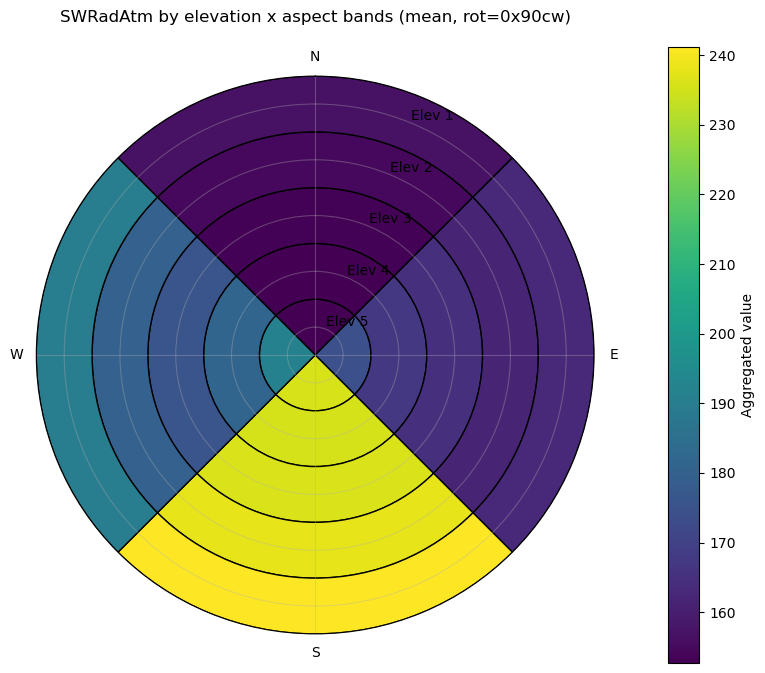

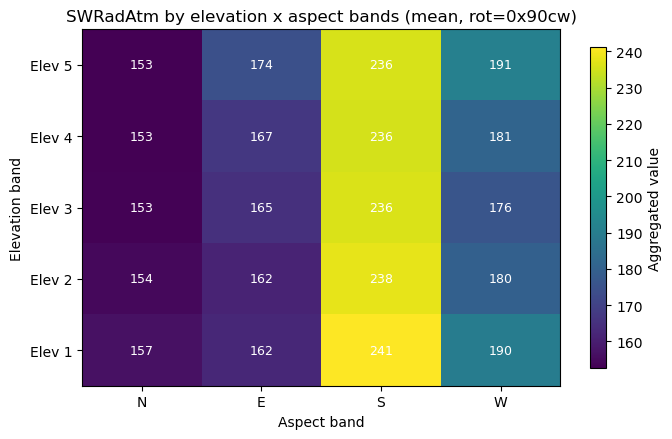

Combined aggregation summary:


,variable,stat_mode,elev_band,aspect_band,stat_value,hru_count,band_area_m2
0,SWRadAtm,mean,1,E,162.413058,1,2.313847e+07
1,SWRadAtm,mean,1,N,156.533516,1,1.454752e+07
2,SWRadAtm,mean,1,S,241.177613,1,1.533890e+07
3,SWRadAtm,mean,1,W,189.990508,1,2.027969e+07
4,SWRadAtm,mean,2,E,161.521255,1,6.693528e+07
5,SWRadAtm,mean,2,N,154.442993,1,4.540145e+07
6,SWRadAtm,mean,2,S,237.875730,1,5.659789e+07
7,SWRadAtm,mean,2,W,179.889393,1,6.489230e+07
8,SWRadAtm,mean,3,E,164.961264,1,6.224913e+07
9,SWRadAtm,mean,3,N,153.240658,1,3.388082e+07


In [36]:
# ------------------------------------------------------------------
# Aggregation + visualization controls
# ------------------------------------------------------------------
FORCING_VARIABLES = ['SWRadAtm']  # Example: ['SWRadAtm', 'pptrate', 'airtemp']
STAT_MODE = 'mean'                 # 'mean' or 'sum'
FILE_LIMIT = 20                  # Optional: set to an integer for quick testing
PLOT_CMAP = 'viridis'

# Positive values rotate aspect assignment clockwise:
# 0 = no rotation, 1 = 90 deg, 2 = 180 deg, 3 = 270 deg.
ASPECT_ROTATION_STEPS_CLOCKWISE = 0

selected_files = forcing_files if FILE_LIMIT is None else forcing_files[:FILE_LIMIT]
if not selected_files:
    raise ValueError('No forcing files selected')

print(f'Selected files: {len(selected_files)}')
print(f'Variables: {FORCING_VARIABLES}')
print(f'Stat mode: {STAT_MODE}')
print(f'Aspect class map in use: {aspect_class_map}')
print(f'Aspect rotation (clockwise 90 deg steps): {ASPECT_ROTATION_STEPS_CLOCKWISE}')
print(f"On-the-fly SW correction active: {bool(config.get('APPLY_ASPECT_SW_CORRECTION', False))}")

all_results = []

for var_name in FORCING_VARIABLES:
    chunks = []
    missing_var_files = 0

    for f in selected_files:
        with xr.open_dataset(f) as ds_raw:
            if var_name not in ds_raw:
                missing_var_files += 1
                continue
            if var_name == 'pptrate':
                if 'pptrate' in ds_raw:
                    ds_raw['pptrate'] = ds_raw['pptrate'] * 86400 * 365
                else:
                    missing_var_files += 1
                    continue
            ds_part = ds_raw[[var_name]].copy()

            if 'hruId' in ds_raw:
                ds_part['hruId'] = ('hru', ds_raw['hruId'].values.astype(int))
            elif 'hruId' in ds_raw.coords:
                ds_part['hruId'] = ('hru', ds_raw.coords['hruId'].values.astype(int))
            elif 'hru' in ds_raw.coords:
                ds_part['hruId'] = ('hru', ds_raw.coords['hru'].values.astype(int))
            elif 'hru' in ds_part.dims:
                ds_part['hruId'] = ('hru', np.arange(ds_part.sizes['hru'], dtype=int) + 1)
            else:
                raise KeyError(f'Could not resolve hruId for file: {f.name}')

            if not np.issubdtype(ds_part['time'].dtype, np.number):
                ds_part = pre._fix_time_coordinate_comprehensive(ds_part, f.name)

            # Apply SW correction in-notebook only when requested.
            if var_name == 'SWRadAtm' and bool(config.get('APPLY_ASPECT_SW_CORRECTION', False)):
                ds_part = pre._apply_aspect_shortwave_correction(ds_part, f.name)

            if MAX_HOURS is not None:
                ds_part = ds_part.isel(time=slice(0, MAX_HOURS))

            chunks.append(ds_part.load())

    if not chunks:
        print(f"Skipping {var_name}: variable not found in selected files")
        continue

    if missing_var_files > 0:
        print(f"Variable {var_name}: missing in {missing_var_files} file(s), processed remaining files")

    ds_var = xr.concat(chunks, dim='time') if len(chunks) > 1 else chunks[0]

    agg_df = aggregate_by_elev_aspect(
        ds=ds_var,
        gdf=gdf,
        var_name=var_name,
        stat_mode=STAT_MODE,
        hru_col=hru_col,
        area_col=area_col,
        elev_col=elev_col,
        aspect_col=aspect_col,
        aspect_class_map=aspect_class_map,
        aspect_rotation_steps_clockwise=ASPECT_ROTATION_STEPS_CLOCKWISE,
    )
    agg_df.insert(0, 'variable', var_name)
    agg_df.insert(1, 'stat_mode', STAT_MODE.lower())
    all_results.append(agg_df)

    display(agg_df)

    plot_elev_aspect_compass(
        agg_df,
        title=f"{var_name} by elevation x aspect bands ({STAT_MODE}, rot={ASPECT_ROTATION_STEPS_CLOCKWISE}x90cw)",
        cmap=PLOT_CMAP,
    )
    plot_elev_aspect_heatmap(
        agg_df,
        title=f"{var_name} by elevation x aspect bands ({STAT_MODE}, rot={ASPECT_ROTATION_STEPS_CLOCKWISE}x90cw)",
        cmap=PLOT_CMAP,
    )

if not all_results:
    raise ValueError('No aggregation output generated. Check selected variables and files.')

band_summary = pd.concat(all_results, ignore_index=True)
print('Combined aggregation summary:')
display(band_summary)

In [22]:
# HRU alignment + elevation-sequence diagnostic for temperature
TEMP_VAR = 'airtemp'
TEMP_FILE_LIMIT = None  # Set an integer for a quick test

files_for_temp = forcing_files if TEMP_FILE_LIMIT is None else forcing_files[:TEMP_FILE_LIMIT]
if not files_for_temp:
    raise ValueError('No forcing files available for temperature diagnostic')

def _prepare_temp_dataset(ds_raw, var_name, file_name):
    if var_name not in ds_raw:
        return None

    ds_part = ds_raw[[var_name]].copy()

    if 'hruId' in ds_raw:
        ds_part['hruId'] = ('hru', np.asarray(ds_raw['hruId'].values).astype(int))
    elif 'hruId' in ds_raw.coords:
        ds_part['hruId'] = ('hru', np.asarray(ds_raw.coords['hruId'].values).astype(int))
    elif 'hru' in ds_raw.coords:
        ds_part['hruId'] = ('hru', np.asarray(ds_raw.coords['hru'].values).astype(int))
    elif 'hru' in ds_part.dims:
        ds_part['hruId'] = ('hru', np.arange(ds_part.sizes['hru'], dtype=int) + 1)
    else:
        raise KeyError(f'Could not resolve hruId for file: {file_name}')

    if not np.issubdtype(ds_part['time'].dtype, np.number):
        ds_part = pre._fix_time_coordinate_comprehensive(ds_part, file_name)

    return ds_part

# 1) HRU ID alignment check on first file
with xr.open_dataset(files_for_temp[0]) as ds0_raw:
    ds0 = _prepare_temp_dataset(ds0_raw, TEMP_VAR, files_for_temp[0].name)
    if ds0 is None:
        raise KeyError(f"{TEMP_VAR} not found in first forcing file: {files_for_temp[0].name}")

forcing_hru_ids = extract_hru_ids(ds0)
shape_hru_ids = pd.to_numeric(gdf[hru_col], errors='coerce').dropna().astype(int).unique()
shape_hru_ids_sorted = np.sort(shape_hru_ids)

missing_in_shape = np.setdiff1d(forcing_hru_ids, shape_hru_ids)
missing_in_forcing = np.setdiff1d(shape_hru_ids, forcing_hru_ids)

n_pos = min(len(forcing_hru_ids), len(shape_hru_ids_sorted))
position_match_fraction = float(np.mean(forcing_hru_ids[:n_pos] == shape_hru_ids_sorted[:n_pos])) if n_pos > 0 else np.nan

print('HRU ID alignment checks')
print('-----------------------')
print(f'Forcing HRU count: {len(forcing_hru_ids)}')
print(f'Shapefile HRU count: {len(shape_hru_ids)}')
print(f'Missing in shapefile: {len(missing_in_shape)}')
print(f'Missing in forcing: {len(missing_in_forcing)}')
print(f'Positional match fraction vs sorted shapefile IDs: {position_match_fraction:.3f}')

if len(missing_in_shape) > 0:
    print('Sample forcing IDs missing in shapefile:', missing_in_shape[:10])
if len(missing_in_forcing) > 0:
    print('Sample shapefile IDs missing in forcing:', missing_in_forcing[:10])

# 2) Compute per-HRU mean temperature over selected files (ID-based mapping)
temp_chunks = []
missing_temp_files = 0

for f in files_for_temp:
    with xr.open_dataset(f) as dsi_raw:
        dsi = _prepare_temp_dataset(dsi_raw, TEMP_VAR, f.name)
        if dsi is None:
            missing_temp_files += 1
            continue
        temp_chunks.append(dsi.load())

if not temp_chunks:
    raise ValueError(f'No {TEMP_VAR} data found in selected files')

if missing_temp_files > 0:
    print(f'{TEMP_VAR} missing in {missing_temp_files} file(s); used remaining files')

temp_ds = xr.concat(temp_chunks, dim='time') if len(temp_chunks) > 1 else temp_chunks[0]
temp_da = to_time_hru(temp_ds[TEMP_VAR]).astype(float)
temp_hru_ids = extract_hru_ids(temp_ds)
temp_per_hru = temp_da.mean(dim='time', skipna=True).to_numpy()

lookup_cols = [hru_col, area_col, elev_col]
lookup = gdf[lookup_cols].copy()
lookup[hru_col] = pd.to_numeric(lookup[hru_col], errors='coerce').astype('Int64')
lookup = lookup.dropna(subset=[hru_col]).copy()
lookup[hru_col] = lookup[hru_col].astype(int)
lookup[area_col] = pd.to_numeric(lookup[area_col], errors='coerce').fillna(1.0)
lookup[elev_col] = pd.to_numeric(lookup[elev_col], errors='coerce')

temp_df = pd.DataFrame({hru_col: temp_hru_ids, 'temp_mean': temp_per_hru})
temp_df = temp_df.merge(lookup, on=hru_col, how='left')

# Optional continuous elevation column for true high-to-low ordering
elev_value_candidates = [
    'elevation', 'elev_mean', 'ELEV_MEAN', 'meanElev', 'elev_m', 'elev',
    'DEM_mean', 'dem_mean', 'avg_elev', 'avgElev',
]
elev_value_col = next((c for c in elev_value_candidates if c in gdf.columns), None)

if elev_value_col is not None:
    elev_extra = gdf[[hru_col, elev_value_col]].copy()
    elev_extra[hru_col] = pd.to_numeric(elev_extra[hru_col], errors='coerce').astype('Int64')
    elev_extra[elev_value_col] = pd.to_numeric(elev_extra[elev_value_col], errors='coerce')
    elev_extra = elev_extra.dropna(subset=[hru_col]).copy()
    elev_extra[hru_col] = elev_extra[hru_col].astype(int)
    temp_df = temp_df.merge(elev_extra, on=hru_col, how='left', suffixes=('', '_extra'))

# Class-level area-weighted temperature
class_rows = []
for cls, sub in temp_df.dropna(subset=[elev_col, 'temp_mean']).groupby(elev_col):
    vals = sub['temp_mean'].to_numpy(dtype=float)
    w = np.maximum(sub[area_col].to_numpy(dtype=float), 1.0)
    class_rows.append(
        {
            'elev_class': int(cls),
            'temp_mean_area_weighted': float(np.average(vals, weights=w)),
            'hru_count': int(len(sub)),
            'area_m2': float(np.sum(w)),
        }
    )

class_temp_df = pd.DataFrame(class_rows).sort_values('elev_class').reset_index(drop=True)

if elev_value_col is not None and elev_value_col in temp_df.columns:
    elev_rows = []
    for cls, sub in temp_df.dropna(subset=[elev_col, elev_value_col]).groupby(elev_col):
        elev_vals = sub[elev_value_col].to_numpy(dtype=float)
        w = np.maximum(sub[area_col].to_numpy(dtype=float), 1.0)
        elev_rows.append(
            {
                'elev_class': int(cls),
                'class_mean_elevation_m': float(np.average(elev_vals, weights=w)),
            }
        )

    class_elev_df = pd.DataFrame(elev_rows)
    class_temp_df = class_temp_df.merge(class_elev_df, on='elev_class', how='left')
    class_temp_df = class_temp_df.sort_values('class_mean_elevation_m', ascending=False).reset_index(drop=True)

    if len(class_temp_df) >= 2:
        top = class_temp_df.iloc[0]
        bottom = class_temp_df.iloc[-1]
        print('\nHigh-to-low elevation sequence check')
        print('-----------------------------------')
        print(f"Highest class by elevation: class {int(top['elev_class'])}, elev={top['class_mean_elevation_m']:.1f} m, temp={top['temp_mean_area_weighted']:.3f}")
        print(f"Lowest class by elevation: class {int(bottom['elev_class'])}, elev={bottom['class_mean_elevation_m']:.1f} m, temp={bottom['temp_mean_area_weighted']:.3f}")
        lapse_ok = top['temp_mean_area_weighted'] <= bottom['temp_mean_area_weighted']
        print(f'Temperature decreases with elevation (expected): {bool(lapse_ok)}')

    hru_lapse_df = temp_df.dropna(subset=[elev_value_col, 'temp_mean']).copy()
    if len(hru_lapse_df) >= 3:
        slope, intercept = np.polyfit(
            hru_lapse_df[elev_value_col].to_numpy(dtype=float),
            hru_lapse_df['temp_mean'].to_numpy(dtype=float),
            1,
        )
        print(f'HRU-level dT/dz slope: {slope:.6f} [temperature units]/m (expected negative for K or C)')
else:
    print('\nNo continuous elevation field found in shapefile; showing class IDs only.')

print('\nClass-level temperature summary')
print('-------------------------------')
display(class_temp_df)

# 3) Naive positional vs ID-based mapping sanity check
lookup_sorted = lookup.sort_values(hru_col).reset_index(drop=True)
n = min(len(lookup_sorted), len(temp_per_hru))
naive = lookup_sorted.iloc[:n].copy()
naive['temp_mean_naive_position'] = temp_per_hru[:n]

id_merge = temp_df[[hru_col, 'temp_mean']].merge(
    lookup_sorted[[hru_col, elev_col]],
    on=hru_col,
    how='inner',
)

print('\nNaive positional vs ID-based mapping sanity')
print('------------------------------------------')
print(f'Rows compared: {n}')
print(f'ID-based mapped rows: {len(id_merge)}')

if len(id_merge) == n and n > 0:
    abs_diff = np.abs(id_merge['temp_mean'].to_numpy() - naive['temp_mean_naive_position'].to_numpy())
    print(f'Mean absolute diff (ID-based vs naive positional): {float(np.mean(abs_diff)):.6f}')
    print(f'Max absolute diff (ID-based vs naive positional): {float(np.max(abs_diff)):.6f}')
else:
    print('Could not do 1:1 comparison due to row-count mismatch.')

temp_alignment_summary = {
    'forcing_hru_count': int(len(forcing_hru_ids)),
    'shape_hru_count': int(len(shape_hru_ids)),
    'missing_in_shape': int(len(missing_in_shape)),
    'missing_in_forcing': int(len(missing_in_forcing)),
    'position_match_fraction': float(position_match_fraction),
}

print('\nAlignment summary dict:')
print(temp_alignment_summary)

HRU ID alignment checks
-----------------------
Forcing HRU count: 25
Shapefile HRU count: 25
Missing in shapefile: 0
Missing in forcing: 0
Positional match fraction vs sorted shapefile IDs: 1.000

High-to-low elevation sequence check
-----------------------------------
Highest class by elevation: class 5, elev=3997.1 m, temp=271.726
Lowest class by elevation: class 1, elev=2685.6 m, temp=276.740
Temperature decreases with elevation (expected): True
HRU-level dT/dz slope: -0.003972 [temperature units]/m (expected negative for K or C)

Class-level temperature summary
-------------------------------


,elev_class,temp_mean_area_weighted,hru_count,area_m2,class_mean_elevation_m
0,5,271.726473,5,3.900219e+06,3997.061872
1,4,273.177214,5,7.994640e+07,3695.141308
2,3,274.703914,5,2.339172e+08,3361.449439
3,2,276.091017,5,2.780548e+08,3012.050327
4,1,276.740364,5,1.524332e+08,2685.610143



Naive positional vs ID-based mapping sanity
------------------------------------------
Rows compared: 25
ID-based mapped rows: 25
Mean absolute diff (ID-based vs naive positional): 0.000000
Max absolute diff (ID-based vs naive positional): 0.000000

Alignment summary dict:
{'forcing_hru_count': 25, 'shape_hru_count': 25, 'missing_in_shape': 0, 'missing_in_forcing': 0, 'position_match_fraction': 1.0}


## TODO
- Recreate the landsurface dataset once the updated landsurface inputs are pulled in.